<div align=center>

# Machine Learning Research Project

## Topic: FEATURE SCALING

</div>

## Project Overview

This research project investigates the effect of feature scaling on machine learning classification models using the Wine dataset. The dataset contains chemical measurements of wines from three different classes.

The project compares the performance of a **K-Nearest Neighbors (KNN)** classifier and a **Decision Tree** classifier using both scaled and unscaled data. Standardization is applied using `StandardScaler`, transforming the features to a comparable scale with a mean of zero and a standard deviation of one.

Model performance is evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices. The results indicate that feature scaling significantly improves KNN performance, increasing its accuracy from approximately **80.56%** on unscaled data to **97.22%** on scaled data. In contrast, the Decision Tree achieves the same accuracy of **94.44%** with or without scaling.

Overall, this study demonstrates that feature scaling is particularly important for distance-based algorithms such as KNN, while tree-based models are generally unaffected by differences in feature magnitude.

Importing Dataset and Libraries

In [1]:


#importing necessary modules and libraries
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             classification_report,
                             confusion_matrix)

Loading Datasets

In [16]:
wine = load_wine()

X = wine.data
y = wine.target

Dataset Information

In [17]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nClasses:", wine.target_names)

print("\nFeature names:")
print(wine.feature_names)

Number of samples: 178
Number of features: 13

Classes: ['class_0' 'class_1' 'class_2']

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 142
Testing samples: 36


Scaling Datasets

In [29]:
scaler = StandardScaler()

x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)


KNN Unscaled : Train KNN Unscaled

In [30]:
knn_unscaled = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn_unscaled.fit(X_train, y_train)

y_pred_knn_unscaled = knn_unscaled.predict(X_test)

KNN Unscaled : Evaluate KNN Unscaled

In [42]:

accuracy_knn_unscaled = accuracy_score(y_test, y_pred_knn_unscaled)
recall_knn_unscaled = recall_score(y_test, y_pred_knn_unscaled, average='weighted')
precision_knn_unscaled = precision_score(y_test, y_pred_knn_unscaled, average='weighted')
f1_knn_unscaled = f1_score(y_test, y_pred_knn_unscaled, average='weighted')

print("KNN - Unscaled")
print("Accuracy:", accuracy_knn_unscaled)
print("Precision:", precision_knn_unscaled)
print("Recall:", recall_knn_unscaled)
print("F1 Score:", f1_knn_unscaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_unscaled))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_unscaled))

KNN - Unscaled
Accuracy: 0.8055555555555556
Precision: 0.8092463092463092
Recall: 0.8055555555555556
F1 Score: 0.8065843621399177

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.77      0.71      0.74        14
           2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36

Confusion Matrix:
[[12  0  0]
 [ 0 10  4]
 [ 0  3  7]]


KNN Scaled :  Train KNN Scaled

In [32]:


knn_scaled = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn_scaled.fit(x_train_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(x_test_scaled)

KNN Scaled : Evaluate KNN Scaled

In [43]:
accuracy_knn_scaled = accuracy_score(y_test, y_pred_knn_scaled)
recall_knn_scaled = recall_score(y_test, y_pred_knn_scaled, average='weighted')
precision_knn_scaled = precision_score(y_test, y_pred_knn_scaled, average='weighted')
f1_knn_scaled = f1_score(y_test, y_pred_knn_scaled, average='weighted')

print("KNN - Scaled")
print("Accuracy:", accuracy_knn_scaled)
print("Recall:", recall_knn_scaled)
print("Precision:", precision_knn_scaled)
print("F1 Score:", f1_knn_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_scaled))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_scaled))

KNN - Scaled
Accuracy: 0.9722222222222222
Recall: 0.9722222222222222
Precision: 0.9747474747474748
F1 Score: 0.9723691945914168

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]


Decision Tree Unscaled : Train Decision Tree Unscaled

In [34]:
dt_unscaled = DecisionTreeClassifier(random_state=42)

dt_unscaled.fit(X_train, y_train)

y_pred_dt_unscaled = dt_unscaled.predict(X_test)

Decision Tree Unscaled : Evaluate Decision Tree Unscaled

In [44]:
accuracy_dt_unscaled = accuracy_score(y_test, y_pred_dt_unscaled)
recall_dt_unscaled = recall_score(y_test, y_pred_dt_unscaled, average='weighted')
precision_dt_unscaled = precision_score(y_test, y_pred_dt_unscaled, average='weighted')
f1_dt_unscaled = f1_score(y_test, y_pred_dt_unscaled, average='weighted')
print("Decision Tree - Unscaled")
print("Accuracy:", accuracy_dt_unscaled)
print("Recall:", recall_dt_unscaled)
print("Precision:", precision_dt_unscaled)
print("F1 Score:", f1_dt_unscaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_unscaled))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_unscaled))

Decision Tree - Unscaled
Accuracy: 0.9444444444444444
Recall: 0.9444444444444444
Precision: 0.9513888888888888
F1 Score: 0.9449614374099499

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


Decision Tree Scaled : Train Decision Tree Scaled

In [36]:
dt_scaled = DecisionTreeClassifier(random_state=42)

dt_scaled.fit(x_train_scaled, y_train)

y_pred_dt_scaled = dt_scaled.predict(x_test_scaled)

Decision Tree Scaled : Evaluate Decision Tree Scaled

In [46]:
accuracy_dt_scaled = accuracy_score(y_test, y_pred_dt_scaled)
recall_dt_scaled = recall_score(y_test, y_pred_dt_scaled, average='weighted')
precision_dt_scaled = precision_score(y_test, y_pred_dt_scaled, average='weighted')
f1_dt_scaled = f1_score(y_test, y_pred_dt_scaled, average='weighted')

print("Decision Tree - Scaled")
print("Accuracy:", accuracy_dt_scaled)
print("Recall:", recall_dt_scaled)
print("Precision:", precision_dt_scaled)
print("F1 Score:", f1_dt_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_scaled))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_scaled))

Decision Tree - Scaled
Accuracy: 0.9444444444444444
Recall: 0.9444444444444444
Precision: 0.9513888888888888
F1 Score: 0.9449614374099499

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


Data Visualisation and Comparison

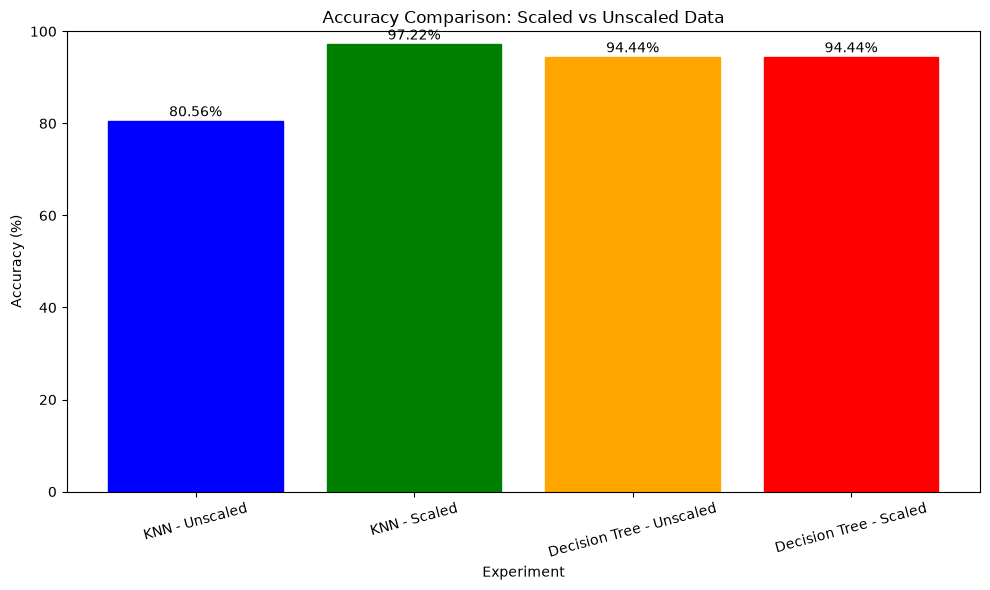

In [39]:


models = [
    "KNN - Unscaled",
    "KNN - Scaled",
    "Decision Tree - Unscaled",
    "Decision Tree - Scaled"
]

accuracies = [
    accuracy_knn_unscaled,
    accuracy_knn_scaled,
    accuracy_dt_unscaled,
    accuracy_dt_scaled
]

plt.figure(figsize=(10, 6))

bars = plt.bar(models, [accuracy * 100 for accuracy in accuracies])
colors = ['blue', 'green', 'orange', 'red']
plt.ylabel("Accuracy (%)")
plt.xlabel("Experiment")
plt.title("Accuracy Comparison: Scaled vs Unscaled Data")
plt.ylim(0, 100)

for bar, accuracy , color in zip(bars, accuracies, colors):
    bar.set_color(color)
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy * 100:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()